In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def separate_sides(pi_data):
    left_df = pi_data[pi_data['foot'] == 'left']
    right_df = pi_data[pi_data['foot'] == 'right']

    left_data = pi_reshape(left_df)
    right_data = pi_reshape(right_df)
    return left_data, right_data
def pi_reshape(side_df):
    """
    reshapes continuous df to 3D array [31 x 11 x number of frames]
    :param side_df: continuous df
    :return: 3d array [31 x 11 x number of frames]
    """
    frames = side_df['frame'].unique()
    side_array = np.empty([31,11,frames[-1]])
    for i in frames:
        side_array[:, :, i - 1] = side_df.loc[side_df['frame'] == i, '0':'10'].values
    return side_array
def pi_force(array3):
    return np.sum(np.sum(array3, axis=0), axis=0)
def pi_ic(force_side, sampling_rate):

    # calculate rate of force development (1st derivative of force)
    rfd = np.diff(force_side, n=1)*sampling_rate   # unit N/s

    # find where rfd > 1500 N/s based on Seiberl et al. (2018)
    rfd_1500 = np.where(rfd > 1500)[0]
    rfd_1500 = list(rfd_1500[rfd_1500<len(force_side)-sampling_rate//20])
    IC_side = []

    # loop over all indices of rfd_1500
    for IC in rfd_1500:
        # check if force increases monotonically by at least 1000 N in next 0.05s
        # TODO: needs to be checked
        if ((force_side[IC+sampling_rate//20]) > (force_side[IC]+1000)) & (min(force_side[IC:IC+sampling_rate//20]) == force_side[IC:IC+sampling_rate//20][0]):
            # first ic
            if len(IC_side) == 0:
                IC_side.append(IC)
            # all further ic have to be at least 0.25s apart
            elif IC > IC_side[-1]+sampling_rate//4:
                IC_side.append(IC)

    return np.array(IC_side, dtype=int)

In [3]:
df = pd.read_csv('D:\\Salzburg\\Study1\\P01\\P01_PI_df\\BOS_down_8.csv', index_col = 0)
df.set_index(np.linspace(0, len(df)-1, len(df)))
df

,0,1,2,3,4,5,6,7,8,9,10,foot,frame,row_count
0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,left,1,1
1,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,left,1,2
2,0.0,0.0,0.00,0.00,1.35,2.20,1.05,1.50,2.01,1.49,0.0,left,1,3
3,0.0,0.0,0.00,2.35,2.05,1.47,1.54,2.53,3.16,3.39,0.0,left,1,4
4,0.0,0.0,1.14,1.40,0.00,0.00,0.00,1.65,4.18,5.75,0.0,left,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581976,0.0,0.0,0.00,0.00,0.00,1.93,1.59,1.51,0.00,0.00,0.0,right,6000,27
581977,0.0,0.0,0.00,0.00,0.00,1.51,2.24,2.13,1.36,0.00,0.0,right,6000,28
581978,0.0,0.0,0.00,0.00,0.00,1.44,5.16,3.32,1.62,0.00,0.0,right,6000,29
581979,0.0,0.0,0.00,0.00,0.00,1.52,3.48,2.91,1.64,0.00,0.0,right,6000,30


In [4]:
left_raw, right_raw = separate_sides(df)
f_left_raw = np.sum(np.sum(left_raw, axis=0), axis=0)
f_right_raw = np.sum(np.sum(right_raw, axis=0), axis=0)

In [5]:
ic_right = pi_ic(f_right_raw, 100)
ic_left = pi_ic(f_left_raw, 100)

In [65]:
np.mean(f_left_raw[ic_left])+2*np.std(f_left_raw[ic_left])

359.199626948878

In [111]:
ic_left[-3]

5846

In [112]:
tresh = f_left_raw[ic_left[-3]]
where = np.where(f_left_raw < tresh)[0]
where[where>ic_left[-3]][0]

5896

In [37]:
rfd = np.diff(f_left_raw, n=1)*100
rfd_1500 = np.where((rfd < -1500)[0]
to_right=[]
rfd_1500[(rfd_1500 > ic_left[0])&(f_left_raw < f_left_raw)][0]

array([352.88, 347.76, 344.93, ..., 328.3 , 330.67, 329.58])

In [116]:
### Fixed

def pi_to(force_side, IC_side, fs):
    extreme = np.mean(force_side[IC_side])+2*np.std(force_side[IC_side])
    TO_side=[]
    for IC in IC_side[:-1]:
        if force_side[IC] > extreme:
            tresh = extreme
        else:
            tresh = force_side[IC]
        where = np.where(force_side < tresh)[0]
        pot_TO = where[where>(IC+fs//10)][0]
        if pot_TO > IC + fs//10*4:
            print('GCT > 0.4 s ...adjust threshold' )
            tresh = extreme
            where = np.where(force_side < tresh)[0]
            pot_TO = where[where>(IC+fs//10)][0]
        TO_side.append(pot_TO)
    return np.array(TO_side, dtype=int)

In [117]:
100//10*4

40

In [118]:
to = pi_to(f_left_raw, ic_left, 100)

GCT > 0.4 s ...adjust threshold
GCT > 0.4 s ...adjust threshold
GCT > 0.4 s ...adjust threshold
GCT > 0.4 s ...adjust threshold
GCT > 0.4 s ...adjust threshold
GCT > 0.4 s ...adjust threshold
GCT > 0.4 s ...adjust threshold


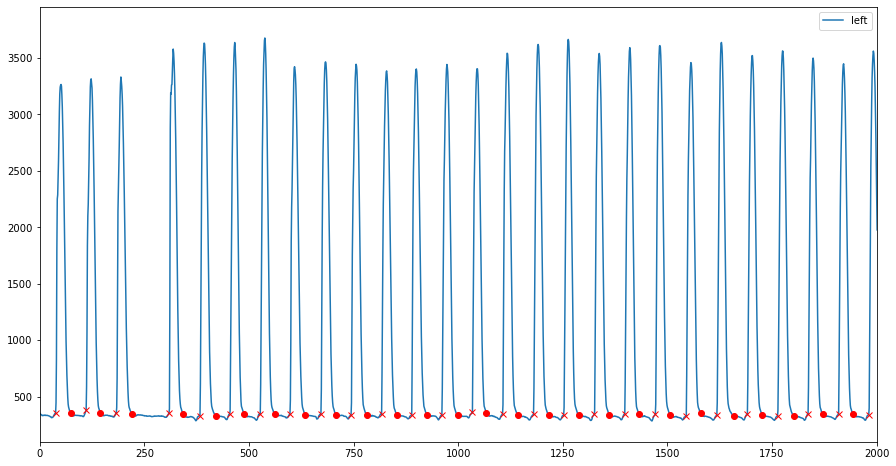

In [123]:
#plt.plot(f_left_raw, label='left')
plt.plot(f_left_raw, label='left')
plt.plot(ic_left, f_left_raw[ic_left], 'rx')
plt.plot(to,f_left_raw[to], 'ro' )
#plt.plot(ic_left, f_left_raw[ic_left], 'bx')
plt.xlim(0,2000)
plt.legend()
fig = plt.gcf()
fig.set_size_inches(15, 8)

In [120]:
ic_left[-3]

5846

In [121]:
to[-2]

5878